In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
data = pd.read_csv("C:/Users/Фантом/Desktop/analyst/online_sales.csv")

In [38]:
data.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [39]:
data['Date'] = pd.to_datetime(data['Date'])

Проверка на пропуски

In [40]:
data.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

Проверка на дубликаты

In [41]:
data.duplicated().sum()

0

### Выбросы

Text(0.5, 0, 'Общий доход за проданный товар за день')

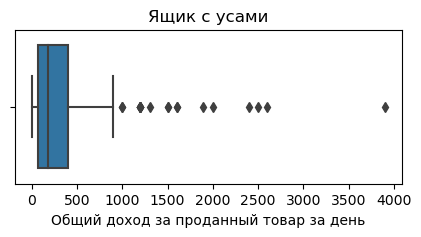

In [42]:
plt.figure(figsize=(5,2))
sns.boxplot(data, x = 'Total Revenue')
plt.title('Ящик с усами')
plt.xlabel('Общий доход за проданный товар за день')

Топ категорий товаров среди выбросов

In [43]:
Q1 = np.quantile(data['Total Revenue'], 0.25)
Q3 = np.quantile(data['Total Revenue'], 0.75)
IQR = Q3 - Q1
upper_whisker = Q3+1.5*IQR
outliers = data[(data['Total Revenue']>upper_whisker)]
outliers.groupby('Product Category')['Units Sold'].count().reset_index()

,Product Category,Units Sold
0,Electronics,14
1,Home Appliances,3
2,Sports,2


Прибыль по месяцам среди выбросов

In [44]:
outliers.set_index('Date').resample('M')['Total Revenue'].sum().to_frame(name='Revenue per month').reset_index()

,Date,Revenue per month
0,2024-01-31,8199.91
1,2024-02-29,5894.92
2,2024-03-31,5399.96
3,2024-04-30,6099.96
4,2024-05-31,2799.98
5,2024-06-30,1199.99
6,2024-07-31,0.00
7,2024-08-31,2399.00


Статистические сведения

In [45]:
data.describe()

,Transaction ID,Date,Units Sold,Unit Price,Total Revenue
count,240.00000,240,240.000000,240.000000,240.000000
mean,10120.50000,2024-04-29 12:00:00,2.158333,236.395583,335.699375
min,10001.00000,2024-01-01 00:00:00,1.000000,6.500000,6.500000
25%,10060.75000,2024-02-29 18:00:00,1.000000,29.500000,62.965000
50%,10120.50000,2024-04-29 12:00:00,2.000000,89.990000,179.970000
75%,10180.25000,2024-06-28 06:00:00,3.000000,249.990000,399.225000
max,10240.00000,2024-08-27 00:00:00,10.000000,3899.990000,3899.990000
std,69.42622,NaN,1.322454,429.446695,485.804469


Объем выборки - 240 заказов.

Самый дорогой товар

In [46]:
data.loc[data['Unit Price'] == 3899.990000]

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
102,10103,2024-04-12,Electronics,Canon EOS R5 Camera,1,3899.99,3899.99,North America,Credit Card


### Топ 5 самых продаваемых товаров

In [47]:
data.groupby('Product Name')['Units Sold'].sum().nlargest(5).reset_index()

,Product Name,Units Sold
0,Hanes ComfortSoft T-Shirt,10
1,The Catcher in the Rye by J.D. Salinger,7
2,Gap Essential Crewneck T-Shirt,6
3,Nike Air Force 1,6
4,Spalding NBA Street Basketball,6


### Топ 5 категорий по количеству продаж

In [48]:
data.groupby('Product Category')['Units Sold'].sum().nlargest(5).reset_index()

,Product Category,Units Sold
0,Clothing,145
1,Books,114
2,Sports,88
3,Electronics,66
4,Home Appliances,59


### Прибыль по месяцам

In [49]:
dynamics_r = data.set_index('Date').resample('M')['Total Revenue'].sum().to_frame(name='Revenue per month').reset_index()
print(dynamics_r)

        Date  Revenue per month
0 2024-01-31           14548.32
1 2024-02-29           10803.37
2 2024-03-31           12849.24
3 2024-04-30           12451.69
4 2024-05-31            8455.49
5 2024-06-30            7384.55
6 2024-07-31            6797.08
7 2024-08-31            7278.11


Text(0.5, 1.0, 'Прибыль по месяцам')

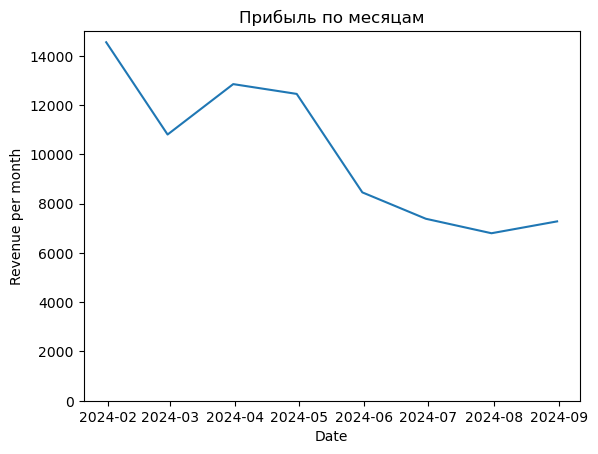

In [50]:
sns.lineplot(data=dynamics_r, x="Date", y="Revenue per month")
plt.ylim(0, 15000)
plt.title('Прибыль по месяцам')

Количество покупок по месяцам

In [51]:
dynamics_n = data.set_index('Date').resample('M')['Total Revenue'].count().to_frame(name='Number of purchases').reset_index()
print(dynamics_n)

        Date  Number of purchases
0 2024-01-31                   31
1 2024-02-29                   29
2 2024-03-31                   31
3 2024-04-30                   30
4 2024-05-31                   31
5 2024-06-30                   30
6 2024-07-31                   31
7 2024-08-31                   27


Text(0.5, 1.0, 'Количество покупок по месяцам')

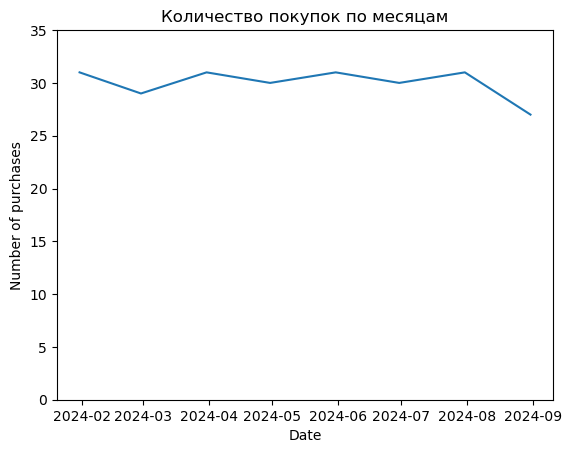

In [52]:
sns.lineplot(data=dynamics_n, x="Date", y="Number of purchases")
plt.ylim(0, 35)
plt.title('Количество покупок по месяцам')

AOV (Average Order Value) - средний чек

In [53]:
dynamics = dynamics_r
dynamics['Number of purchases'] = dynamics_n['Number of purchases']
dynamics['AOV']=(dynamics['Revenue per month']/dynamics['Number of purchases']).round(2)
dynamics

,Date,Revenue per month,Number of purchases,AOV
0,2024-01-31,14548.32,31,469.30
1,2024-02-29,10803.37,29,372.53
2,2024-03-31,12849.24,31,414.49
3,2024-04-30,12451.69,30,415.06
4,2024-05-31,8455.49,31,272.76
5,2024-06-30,7384.55,30,246.15
6,2024-07-31,6797.08,31,219.26
7,2024-08-31,7278.11,27,269.56


Text(0.5, 1.0, 'Средний чек по месяцам')

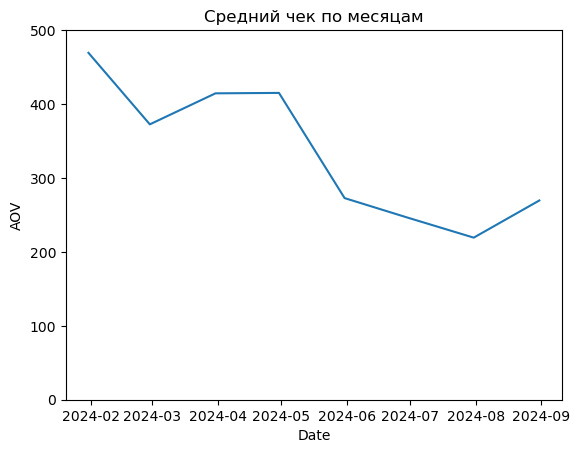

In [54]:
sns.lineplot(data=dynamics, x="Date", y="AOV")
plt.ylim(0, 500)
plt.title('Средний чек по месяцам')

### Популярность категорий товаров по регионам

In [55]:
category_region_sales = data.groupby(['Region', 'Product Category'])['Units Sold'].sum().unstack()
category_region_sales

Product Category,Beauty Products,Books,Clothing,Electronics,Home Appliances,Sports
Region,,,,,,
Asia,NaN,NaN,145.0,NaN,NaN,88.0
Europe,46.0,NaN,NaN,NaN,59.0,NaN
North America,NaN,114.0,NaN,66.0,NaN,NaN


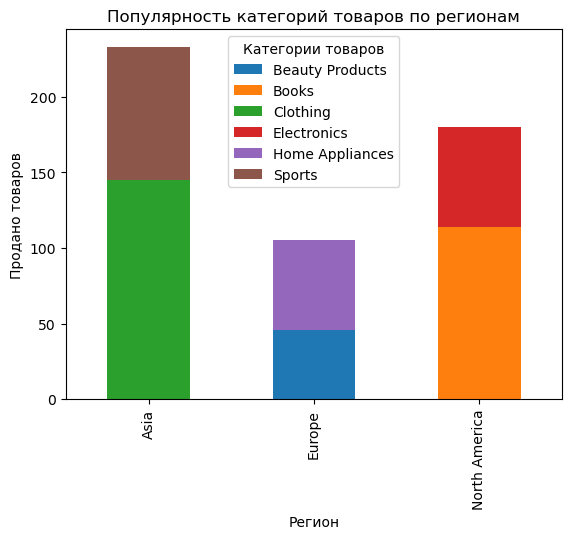

In [56]:
category_region_sales.plot(kind='bar', stacked=True)
plt.title('Популярность категорий товаров по регионам')
plt.xlabel('Регион')
plt.ylabel('Продано товаров')
plt.legend(title='Категории товаров')
plt.show()

### Выводы
1. Топ 5 самых продаваемых товаров:
Hanes ComfortSoft T-Shirt, The Catcher in the Rye by J.D. Salinger, Gap Essential Crewneck T-Shirt, Nike Air Force 1,        Spalding NBA Street Basketball.              

2. Топ 5 категорий по количеству продаж:
одежда, книги, товары для спорта, электроника, товары для дома.     
3. С февраля по сентябрь прибыль в основном падала, но при этом люди не стали меньше покупать, они стали покупать менее дорогие товары. 
4. Пики в январе, апреле и мае обусловлены дорогими покупками. Эти дорогие покупки чаще всего - электроника.
5. В Азии продаются одежда и товары для спорта, в Европе - товары для дома и красоты, в Северной Америке - книги и электроника.

### Топ 3 товара в каждой категории

In [47]:
def get_top_products_by_category(df, top_n=3):
    # Группируем по категории и сортируем по продажам внутри каждой группы
    grouped = df.groupby('Product Category', group_keys=False)
    top_products = grouped.apply(lambda x: x.sort_values('Units Sold', ascending=False).head(top_n))
    
    return top_products.reset_index(drop=True)

# Получаем топ-3 товара для каждой категории
top_products = get_top_products_by_category(data, top_n=3)

# Выводим результат
print("Самые продаваемые товары по категориям:")
print(top_products[['Product Category', 'Product Name', 'Units Sold']])

Самые продаваемые товары по категориям:
   Product Category                             Product Name  Units Sold
0   Beauty Products         CeraVe Hydrating Facial Cleanser           2
1   Beauty Products                 L'Oreal Revitalift Serum           2
2   Beauty Products        L'Occitane Shea Butter Hand Cream           2
3             Books                        The Da Vinci Code           4
4             Books               Becoming by Michelle Obama           4
5             Books  The Catcher in the Rye by J.D. Salinger           4
6          Clothing                Hanes ComfortSoft T-Shirt          10
7          Clothing                         Nike Air Force 1           6
8          Clothing           Gap Essential Crewneck T-Shirt           6
9       Electronics                Amazon Echo Dot (4th Gen)           4
10      Electronics         Anker PowerCore Portable Charger           4
11      Electronics                  Amazon Fire TV Stick 4K           3
12  Home Ap